### Define Stommel Two Box Model 

In [93]:
import numpy as np
import matplotlib.pyplot as plt

class TwoBoxStommel:
    def __init__(self, alpha=2e-4, beta=8e-4, k=1.0, tau_T=50.0, tau_S=1000.0,
                 Tatm1=20.0, Tatm2=0.0, F=0.1, dt=0.1, tmax=5000):
        self.alpha = alpha
        self.beta = beta
        self.k = k
        self.tau_T = tau_T
        self.tau_S = tau_S
        self.Tatm1 = Tatm1
        self.Tatm2 = Tatm2
        self.F = F
        self.dt = dt
        self.tmax = tmax
        self.time = np.arange(0, tmax + dt, dt)
        self.n = len(self.time)
        self.T1 = np.zeros(self.n)
        self.T2 = np.zeros(self.n)
        self.S1 = np.zeros(self.n)
        self.S2 = np.zeros(self.n)
        self.psi = np.zeros(self.n)
        self.T1[0] = Tatm1
        self.T2[0] = Tatm2
        self.S1[0] = 35.0
        self.S2[0] = 34.0

    def step(self, i):
        rho1 = -self.alpha * self.T1[i] + self.beta * self.S1[i]
        rho2 = -self.alpha * self.T2[i] + self.beta * self.S2[i]
        psi = self.k * (rho2 - rho1)
        dT1 = (self.Tatm1 - self.T1[i]) / self.tau_T - psi * (self.T1[i] - self.T2[i])
        dT2 = (self.Tatm2 - self.T2[i]) / self.tau_T + psi * (self.T1[i] - self.T2[i])
        #dS1 = -self.F - psi * (self.S1[i] - self.S2[i])
        #dS2 = self.F + psi * (self.S1[i] - self.S2[i])
        
        dS1 = -self.F / self.tau_S - psi * (self.S1[i] - self.S2[i])
        dS2 = self.F / self.tau_S + psi * (self.S1[i] - self.S2[i])
        self.T1[i + 1] = self.T1[i] + dT1 * self.dt
        self.T2[i + 1] = self.T2[i] + dT2 * self.dt
        self.S1[i + 1] = self.S1[i] + dS1 * self.dt
        self.S2[i + 1] = self.S2[i] + dS2 * self.dt
        self.psi[i + 1] = psi

    def run(self):
        for i in range(self.n - 1):
            self.step(i)

    # def plot(self):
    #     # fig, ax = plt.subplots(2, 1, figsize=(6, 6), sharex=True)
    #     ax[0].plot(self.time, self.T1, label='T1')
    #     ax[0].plot(self.time, self.T2, label='T2')
    #     ax[0].set_ylabel('Temperature')
    #     ax[0].legend()
    #     ax[1].plot(self.time, self.S1, label='S1')
    #     ax[1].plot(self.time, self.S2, label='S2')
    #     ax[1].set_xlabel('Time')
    #     ax[1].set_ylabel('Salinity')
    #     ax[1].legend()
    #     plt.tight_layout()
    #     plt.show()
    #     plt.figure(figsize=(5, 4))
    #     plt.plot(self.time, self.psi)
    #     plt.xlabel('Time')
    #     plt.ylabel('Overturning ψ')
    #     plt.title('Two-Box Stommel Circulation')
    #     plt.grid(True)
    #     plt.tight_layout()
    #     plt.show()


if __name__ == "__main__":
    model = TwoBoxStommel(F=0.2)
    model.run()
    # model.plot()


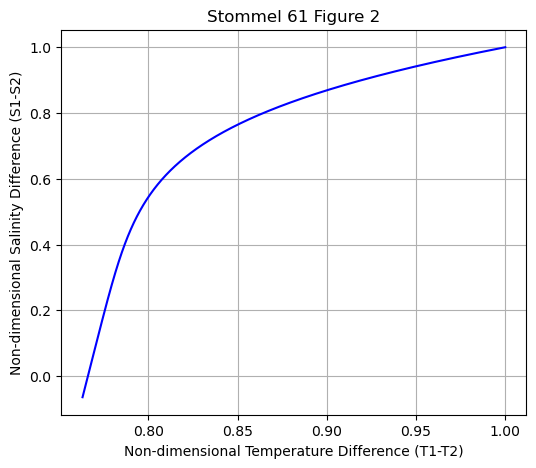

In [96]:
model = TwoBoxStommel(F=0.2)
model.run()

T_nd = (model.T1 - model.T2) / abs(model.Tatm1 - model.Tatm2)
S_nd = (model.S1 - model.S2) / abs(model.S1[0] - model.S2[0])

plt.figure(figsize=(6,5))
plt.plot(T_nd, S_nd, color='blue')
plt.xlabel('Non-dimensional Temperature Difference (T1-T2)')
plt.ylabel('Non-dimensional Salinity Difference (S1-S2)')
plt.title('Stommel 61 Figure 2')
plt.grid(True)
plt.show()


### Figure 4 : steady state exp for diff rates of flow 

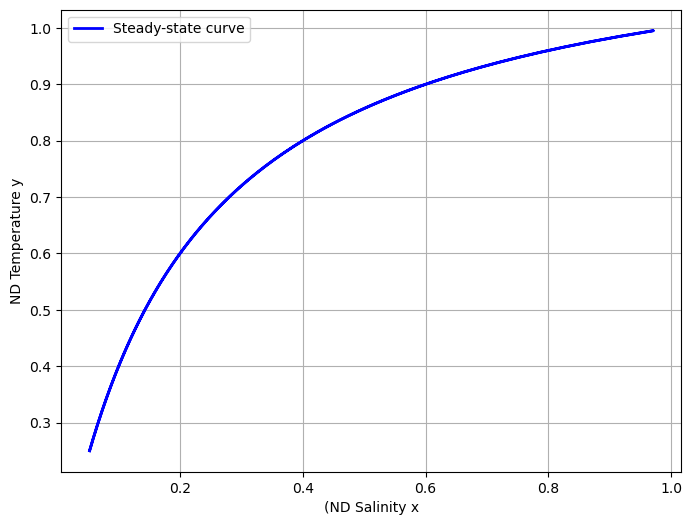

In [143]:
I = 1.0
R = 2.0
delta = 1/6

f_vals = np.linspace(-3, 3, 600)

x_eq = I / (I + np.abs(f_vals)/delta)
y_eq = I / (I + np.abs(f_vals))

plt.figure(figsize=(8,6))
plt.plot(x_eq, y_eq, 'b-', linewidth=2, label='Steady-state curve')

# lhs = (-y_eq + R*x_eq) * 1  
# rhs = f_vals  # f
# diff = lhs - rhs
# zero_crossings = np.where(np.diff(np.sign(diff)) != 0)[0]
# x_points = x_eq[zero_crossings]
# y_points = y_eq[zero_crossings]

# plt.plot(x_points, y_points, 'ro', markersize=6, label='Equilibria for δ=1/6')

plt.xlabel('(ND Salinity x')
plt.ylabel('ND Temperature y')
plt.grid(True)
plt.legend()
plt.show()


### Stommel 61 Two Box Phase Plain Diagram on x, y axis

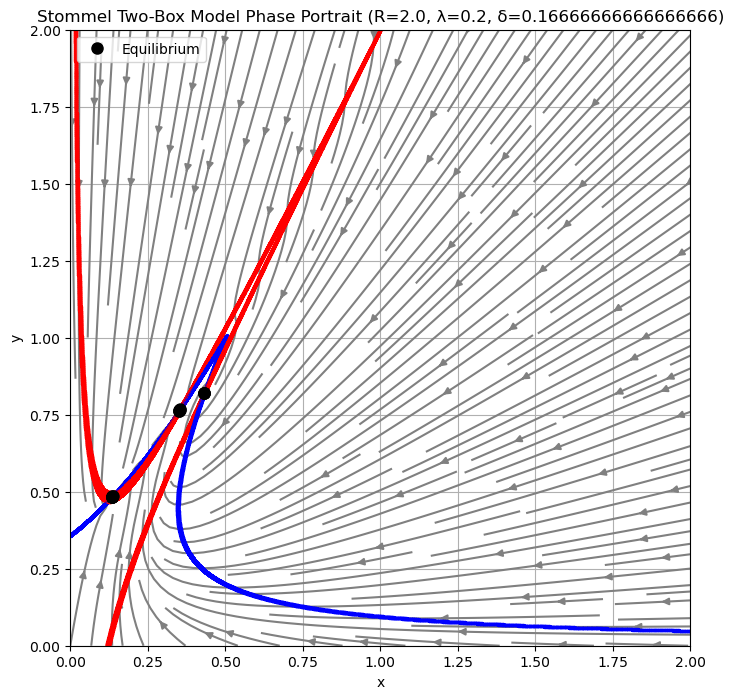

In [118]:

I = 1.0
R = 2.0
lmbda = 1/5
#delta = 1/6  
delta = 1/6 # 


def f(x, y):
    dx = delta * (I - x) - (x / lmbda) * np.abs(-y + R * x)
    dy = I - y - (y / lmbda) * np.abs(-y + R * x)
    return dx, dy

x_range = np.linspace(0, 2.5, 5000)
y_range = np.linspace(0, 2.5, 5000)
xm, ym = np.meshgrid(x_range, y_range)
dxm, dym = f(xm, ym)

plt.figure(figsize=(8, 8))
plt.streamplot(xm, ym, dxm, dym, color='grey', density=2.5)

# numerically
dx_zero = np.zeros_like(x_range)
dy_zero = np.zeros_like(y_range)
for i, x in enumerate(x_range):
    for j, y in enumerate(y_range):
        dx, dy = f(x, y)
        if abs(dx) < 1e-2:
            plt.plot(x, y, 'r.', markersize=2.5)
        if abs(dy) < 1e-2:
            plt.plot(x, y, 'b.', markersize=2.5)

eq_points = []
for x in x_range:
    for y in y_range:
        dx, dy = f(x, y)
        if abs(dx) < 1e-3 and abs(dy) < 1e-3:
            eq_points.append((x, y))

if eq_points:
    eq_points = np.array(eq_points)
    plt.plot(eq_points[:, 0], eq_points[:, 1], 'ko', markersize=8, label='Equilibrium')

plt.xlim(0, 2)
plt.ylim(0, 2)
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'Stommel Two-Box Model Phase Portrait (R={R}, λ={lmbda}, δ={delta})')
plt.grid(True)
plt.legend()
plt.show()


#### Figure 7 

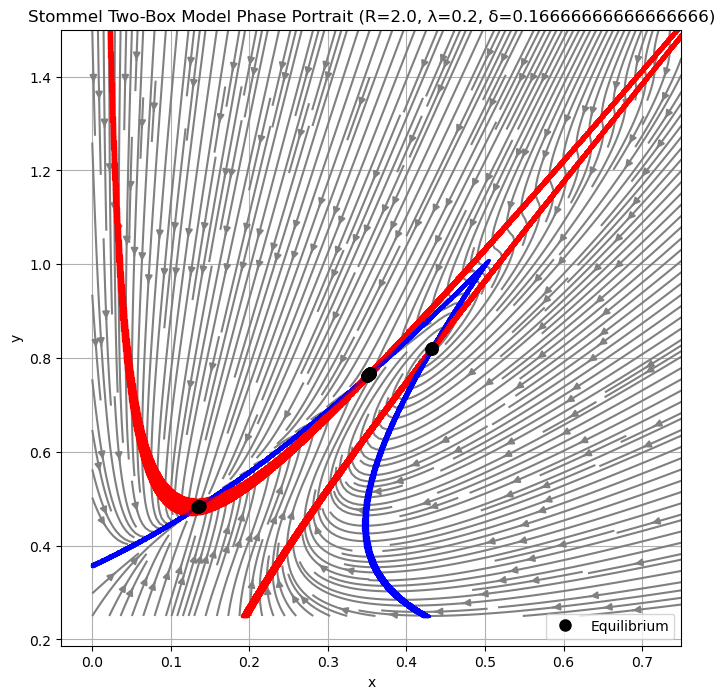

In [129]:

I = 1.0
R = 2.0
lmbda = 1/5
#delta = 1/6  
delta = 1/6 # 


def f(x, y):
    dx = delta * (I - x) - (x / lmbda) * np.abs(-y + R * x)
    dy = I - y - (y / lmbda) * np.abs(-y + R * x)
    return dx, dy

x_range = np.linspace(0, 0.75, 2500)
y_range = np.linspace(0.25, 1.5, 2500)
xm, ym = np.meshgrid(x_range, y_range)
dxm, dym = f(xm, ym)

plt.figure(figsize=(8, 8))
plt.streamplot(xm, ym, dxm, dym, color='grey', density=3.5)

#numerically 
dx_zero = np.zeros_like(x_range)
dy_zero = np.zeros_like(y_range)
for i, x in enumerate(x_range):
    for j, y in enumerate(y_range):
        dx, dy = f(x, y)
        if abs(dx) < 1e-2:
            plt.plot(x, y, 'r.', markersize=2.5)
        if abs(dy) < 1e-2:
            plt.plot(x, y, 'b.', markersize=2.5)

eq_points = []
for x in x_range:
    for y in y_range:
        dx, dy = f(x, y)
        if abs(dx) < 1e-3 and abs(dy) < 1e-3:
            eq_points.append((x, y))

if eq_points:
    eq_points = np.array(eq_points)
    plt.plot(eq_points[:, 0], eq_points[:, 1], 'ko', markersize=8, label='Equilibrium')

# plt.xlim(0, 2)
# plt.ylim(0, 2)
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'Stommel Two-Box Model Phase Portrait (R={R}, λ={lmbda}, δ={delta})')
plt.grid(True)
plt.legend()
plt.show()


#### Figure 8 

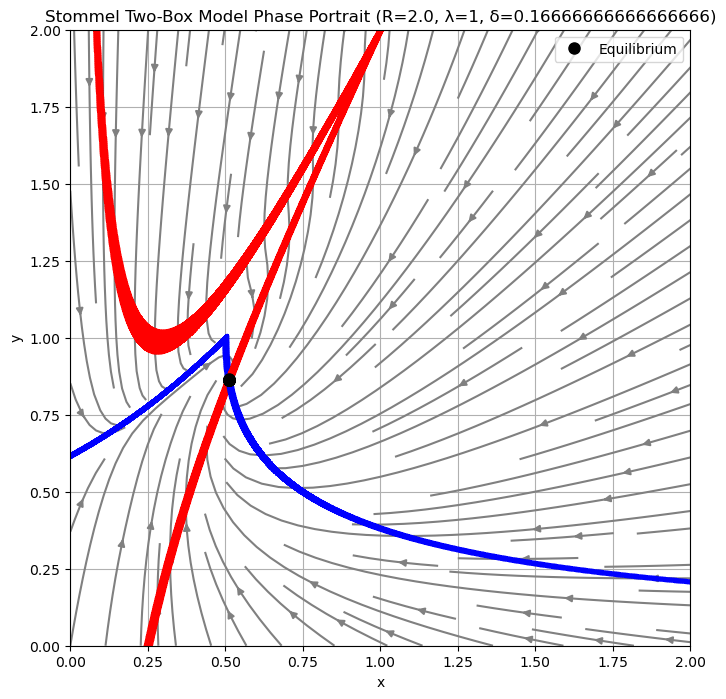

In [117]:

I = 1.0
R = 2.0
lmbda = 1
#delta = 1/6  
delta = 1/6 # 


def f(x, y):
    dx = delta * (I - x) - (x / lmbda) * np.abs(-y + R * x)
    dy = I - y - (y / lmbda) * np.abs(-y + R * x)
    return dx, dy

x_range = np.linspace(0, 2.5, 5000)
y_range = np.linspace(0, 2.5, 5000)
xm, ym = np.meshgrid(x_range, y_range)
dxm, dym = f(xm, ym)

plt.figure(figsize=(8, 8))
plt.streamplot(xm, ym, dxm, dym, color='grey', density=1.5)

# compute nullclines numerically
dx_zero = np.zeros_like(x_range)
dy_zero = np.zeros_like(y_range)
for i, x in enumerate(x_range):
    for j, y in enumerate(y_range):
        dx, dy = f(x, y)
        if abs(dx) < 1e-2:
            plt.plot(x, y, 'r.', markersize=2.5)
        if abs(dy) < 1e-2:
            plt.plot(x, y, 'b.', markersize=2.5)

eq_points = []
for x in x_range:
    for y in y_range:
        dx, dy = f(x, y)
        if abs(dx) < 1e-3 and abs(dy) < 1e-3:
            eq_points.append((x, y))

if eq_points:
    eq_points = np.array(eq_points)
    plt.plot(eq_points[:, 0], eq_points[:, 1], 'ko', markersize=8, label='Equilibrium')

plt.xlim(0, 2)
plt.ylim(0, 2)
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'Stommel Two-Box Model Phase Portrait (R={R}, λ={lmbda}, δ={delta})')
plt.grid(True)
plt.legend()
plt.show()


### Figure 6 

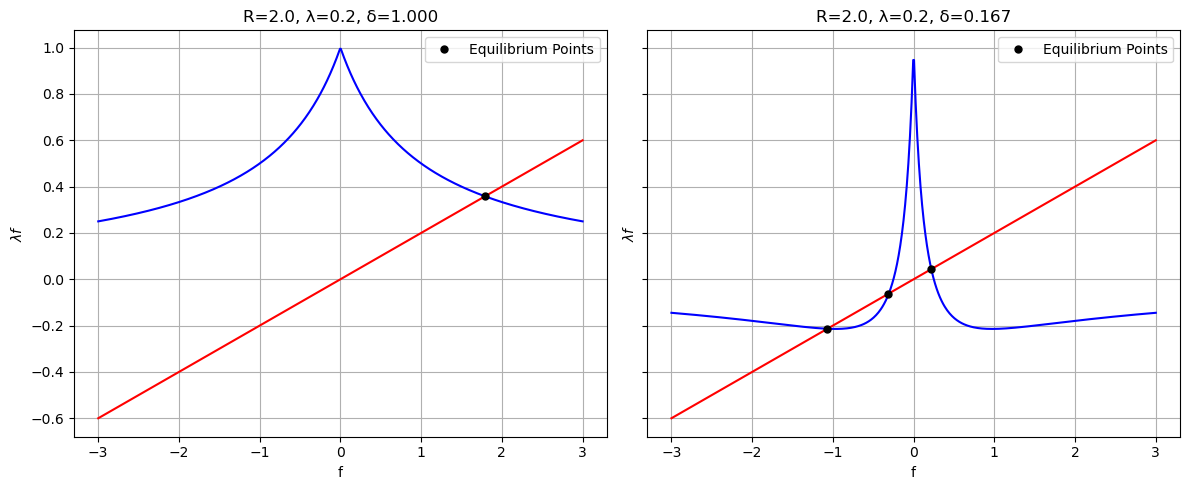

In [125]:
I = 1.0
R = 2.0
lmbda = 1/5
delta_vals = [1, 1/6]

def f_system(x, y, delta):
    abs_term = np.abs(-y + R*x)
    dx = delta*(I - x) - (x/lmbda)*abs_term
    dy = I - y - (y/lmbda)*abs_term
    return dx, dy

def f_from_xy(x, y):
    f = -y + R*x
    return f, lmbda*f

x_range = np.linspace(-3, 3, 200)
y_range = np.linspace(-3, 3, 200)
xm, ym = np.meshgrid(x_range, y_range)
dxm, dym = f_system(xm, ym, delta=1/6)

f_vals = np.linspace(-3,3,200)
lf_vals = np.linspace(-3,3,200)
fm, lfm = np.meshgrid(f_vals, lf_vals)


fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for i, delta in enumerate(delta_vals):
    dxm, dym = f_system(xm, ym, delta)
    
    # streamplot in (x, y) coordinates
    #axes[i].streamplot(xm, ym, dxm, dym, color='grey', density=2.25)

    # dxm, dym = f_system(xm, ym, delta)
    # f_grid = -ym + R*xm
    # lf_grid = lmbda * f_grid
    # df_grid = -dym + R*dxm
    # dlf_grid = lmbda * df_grid
    
    # axes[i].streamplot(f_grid, lf_grid, df_grid, dlf_grid, color='grey', density=2.25)
    # axes[i].streamplot(fm, lfm, df, dlf, color='grey', density=2.25)


    # compute nullclines and equilibria in f, λf space
    f_vals = np.linspace(-3, 3, 600)
    absf = np.abs(f_vals)
    x_nc = I / (I + (absf / delta))
    y_nc = I / (I + absf)
    lhs = lmbda*f_vals
    rhs = -y_nc + R*x_nc
    
    f_nc, lf_nc = f_from_xy(x_nc, y_nc)
    
    axes[i].plot(f_vals, lhs, 'r-')#, label=r'$\lambda f$')
    axes[i].plot(f_vals, rhs, 'b-')#, label=r'$-y + R x$')

    diff = lhs - rhs
    zero_crossings = np.where(np.diff(np.sign(diff)) != 0)[0]
    f_eq_points = f_vals[zero_crossings]
    lhs_eq_points = lhs[zero_crossings]

    axes[i].plot(f_eq_points, lhs_eq_points, 'k', marker='o', markersize=5, linestyle='None', label='Equilibrium Points')
    # # equilibrium point
    # idx = np.argmin(np.abs(lhs - rhs))
    # axes[i].plot(f_vals[idx], lhs[idx], 'k', marker='o', markersize=8, linestyle='None', label='Equilibrium Point')
    
    axes[i].set_title(f'R={R}, λ={lmbda}, δ={delta:.3f}')
    axes[i].set_xlabel('f')
    axes[i].set_ylabel(r'$\lambda f$')
    axes[i].legend()
    axes[i].grid(True)

plt.tight_layout()
#plt.title('Stommel Figure 6 (with trajectories)')
plt.show()
